In [ ]:

!pip install xgboost --quiet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import time

In [ ]:

df = pd.read_csv("StudentPerformance.csv")


df['pass'] = (df['Performance Index'] >= 50).astype(int)

In [ ]:
cat_cols = ['Extracurricular Activities']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(['Performance Index', 'pass'], axis=1)
y = df['pass']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model_cpu = xgb.XGBClassifier(
    tree_method='hist',
    n_estimators=100,
    random_state=42
)

start_cpu = time.time()
model_cpu.fit(X_train, y_train)
cpu_time = time.time() - start_cpu

In [ ]:
y_pred_cpu = model_cpu.predict(X_test)
cpu_acc = accuracy_score(y_test, y_pred_cpu)
cpu_f1 = f1_score(y_test, y_pred_cpu)


In [ ]:
print(f"CPU - Training Time: {cpu_time:.2f}s")
print(f"CPU - Accuracy: {cpu_acc:.4f}")
print(f"CPU - F1 Score: {cpu_f1:.4f}")

CPU - Training Time: 0.39s
CPU - Accuracy: 0.9685
CPU - F1 Score: 0.9731


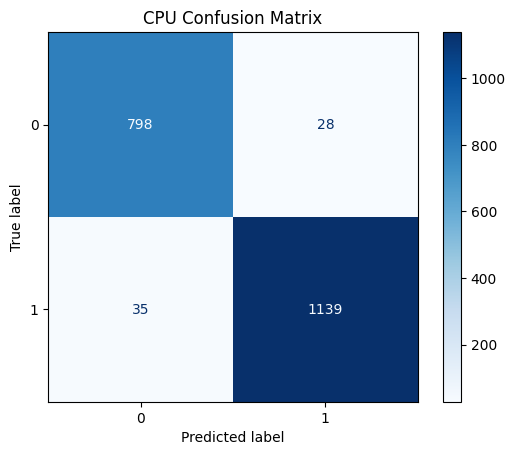

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cpu,
cmap=
'Blues')
plt.title(
"CPU Confusion Matrix")
plt.show()